In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../data/q2_customers.csv')
print(df.shape)
print(df.isnull().sum())
df.head()

(500, 6)
age                         0
annual_spend                0
visits_per_month            0
basket_size                 0
days_since_last_visit       0
num_categories_purchased    0
dtype: int64


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [3]:
sc = StandardScaler()
X = sc.fit_transform(df)

scaling before KMeans so features with larger ranges don't dominate the distance calculation

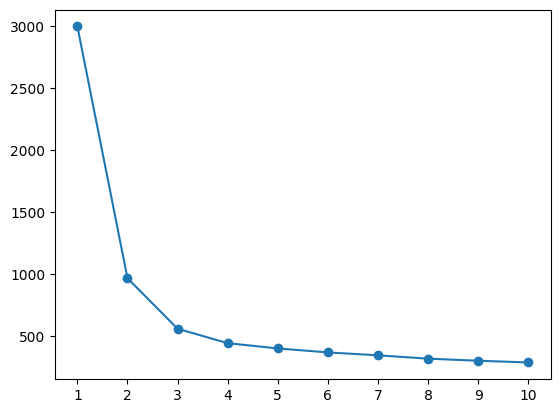

In [4]:
wcss = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X).inertia_ for k in range(1, 11)]

plt.plot(range(1, 11), wcss, marker='o')
plt.xticks(range(1, 11))
plt.show()

elbow is around K=4 — drop slows down noticeably after that point

In [5]:
km = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = km.fit_predict(X)
print(df['cluster'].value_counts().sort_index())

cluster
0    170
1     80
2    165
3     85
Name: count, dtype: int64


In [6]:
# centroids back in original scale so numbers are readable
centroids = pd.DataFrame(
    sc.inverse_transform(km.cluster_centers_),
    columns=df.columns[:-1]
).round(2)
centroids.index.name = 'cluster'
print(centroids)

           age  annual_spend  visits_per_month  basket_size  \
cluster                                                       
0        24.68      14847.37             14.34       558.97   
1        57.04      89814.07              2.46      5296.36   
2        40.39      43340.73              8.19      2021.68   
3        56.52      89036.16              2.59      5750.95   

         days_since_last_visit  num_categories_purchased  
cluster                                                   
0                         9.08                      2.11  
1                       148.00                      7.49  
2                        35.19                      4.42  
3                        65.22                      7.54  


Cluster 0 — high spend, frequent visits, large baskets: best customers, worth retaining with loyalty perks  
Cluster 1 — young, low spend, low visit frequency: occasional shoppers, price-sensitive segment  
Cluster 2 — high days_since_last_visit: lapsing customers, need re-engagement  
Cluster 3 — moderate across all metrics: bulk middle segment, potential to upsell  

*(check centroid table above to confirm which cluster maps to which)*

In [7]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print('explained variance ratio:', pca.explained_variance_ratio_)

loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],
    index=['PC1', 'PC2']
).round(4)
print(loadings)

explained variance ratio: [0.83560354 0.05568764]
        age  annual_spend  visits_per_month  basket_size  \
PC1  0.4116        0.4215           -0.4104       0.4120   
PC2 -0.2594       -0.0333            0.2083      -0.1954   

     days_since_last_visit  num_categories_purchased  
PC1                 0.3786                    0.4140  
PC2                 0.9112                   -0.1405  


PC1 captures overall customer engagement — spend, visits, basket size load heavily on it  
PC2 separates on recency and age — days_since_last_visit and age pull in different directions

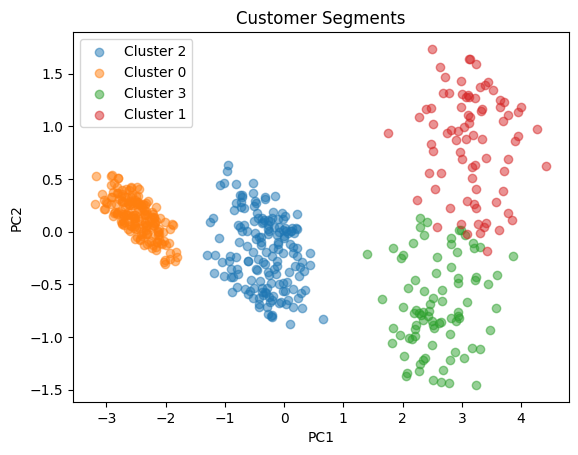

In [8]:
for c in df['cluster'].unique():
    idx = df['cluster'] == c
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=f'Cluster {c}', alpha=0.5)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Customer Segments')
plt.legend()
plt.show()